# **Libraries**

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# **Kaggle GPU Check** 

In [2]:
import tensorflow as tf
import subprocess

print("=" * 60)
print("TensorFlow GPU CHECK")
print("=" * 60)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("\nAvailable GPUs:")
for gpu in gpus:
    print(gpu)

print("\nNumber of GPUs:", len(gpus))

if len(gpus) > 0:
    print("\n✅ GPU is available!")

    strategy = tf.distribute.MirroredStrategy()

    print("Number of replicas:",
          strategy.num_replicas_in_sync)

else:
    print("\n❌ GPU is NOT detected by TensorFlow")

print("\n" + "=" * 60)
print("NVIDIA-SMI")
print("=" * 60)

subprocess.run(["nvidia-smi"])

TensorFlow GPU CHECK
TensorFlow version: 2.20.0

Available GPUs:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

Number of GPUs: 2

✅ GPU is available!
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of replicas: 2

NVIDIA-SMI
Fri Sep 18 05:26:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. 

I0000 00:00:1789709202.265264     184 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789709202.267489     184 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CompletedProcess(args=['nvidia-smi'], returncode=0)

# **Dataset Path**

In [3]:
TRAIN_DIR = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train"
VAL_DIR   = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/val"
TEST_DIR  = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test"

CLASS_NAMES = ['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']

print(os.listdir(TRAIN_DIR))
print(os.listdir(VAL_DIR))
print(os.listdir(TEST_DIR))

['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']


# **Dataset Count Check**

In [4]:
def count_images(directory):
    result = {}

    for cls in CLASS_NAMES:
        class_path = os.path.join(directory, cls)

        if os.path.exists(class_path):
            files = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".webp")
                )
            ]

            result[cls] = len(files)
        else:
            result[cls] = 0

    return result


train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: {'DR': 2300, 'AMD': 2300, 'CSR': 2300, 'DRUSEN': 2300, 'CNV': 2300, 'NORMAL': 2300, 'MH': 2300, 'DME': 2300}
Validation: {'DR': 350, 'AMD': 350, 'CSR': 350, 'DRUSEN': 350, 'CNV': 350, 'NORMAL': 350, 'MH': 350, 'DME': 350}
Test: {'DR': 350, 'AMD': 350, 'CSR': 350, 'DRUSEN': 350, 'CNV': 350, 'NORMAL': 350, 'MH': 350, 'DME': 350}


# **Class Distribution Visualization**

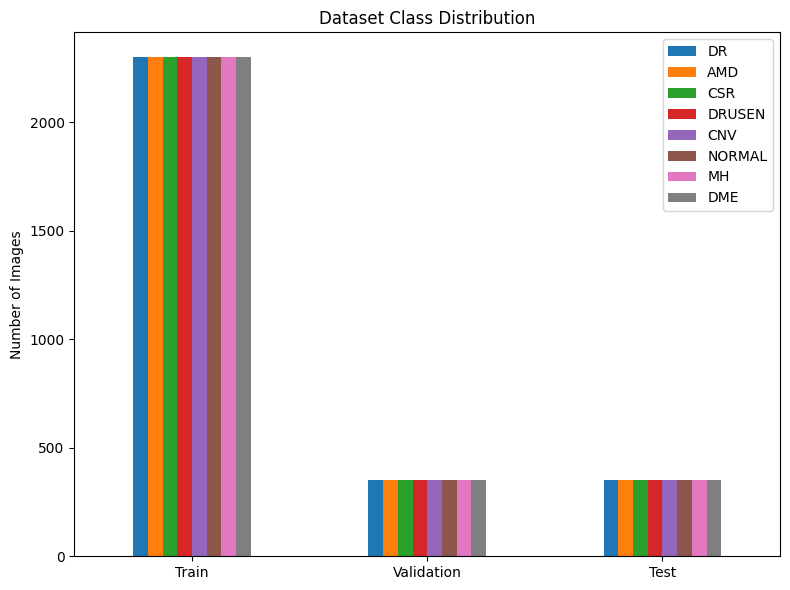

In [5]:
# Create DataFrame
df_distribution = pd.DataFrame({
    "DR":     [train_counts["DR"],     val_counts["DR"],     test_counts["DR"]],
    "AMD":    [train_counts["AMD"],    val_counts["AMD"],    test_counts["AMD"]],
    "CSR":    [train_counts["CSR"],    val_counts["CSR"],    test_counts["CSR"]],
    "DRUSEN": [train_counts["DRUSEN"], val_counts["DRUSEN"], test_counts["DRUSEN"]],
    "CNV":    [train_counts["CNV"],    val_counts["CNV"],    test_counts["CNV"]],
    "NORMAL": [train_counts["NORMAL"], val_counts["NORMAL"], test_counts["NORMAL"]],
    "MH":     [train_counts["MH"],     val_counts["MH"],     test_counts["MH"]],
    "DME":    [train_counts["DME"],    val_counts["DME"],    test_counts["DME"]]
}, index=["Train", "Validation", "Test"])

# Plot
df_distribution.plot(kind="bar", figsize=(8,6))
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Image Size**

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 5

# **Data Generator**

In [7]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

# **Train Generator**

In [8]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

Found 18400 images belonging to 8 classes.


# **Validation Generator**

In [9]:
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

Found 2800 images belonging to 8 classes.


# **Test Generator**

In [10]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print(test_generator.class_indices)

Found 2800 images belonging to 8 classes.
{'DR': 0, 'AMD': 1, 'CSR': 2, 'DRUSEN': 3, 'CNV': 4, 'NORMAL': 5, 'MH': 6, 'DME': 7}


# **Sample Image Visualization**

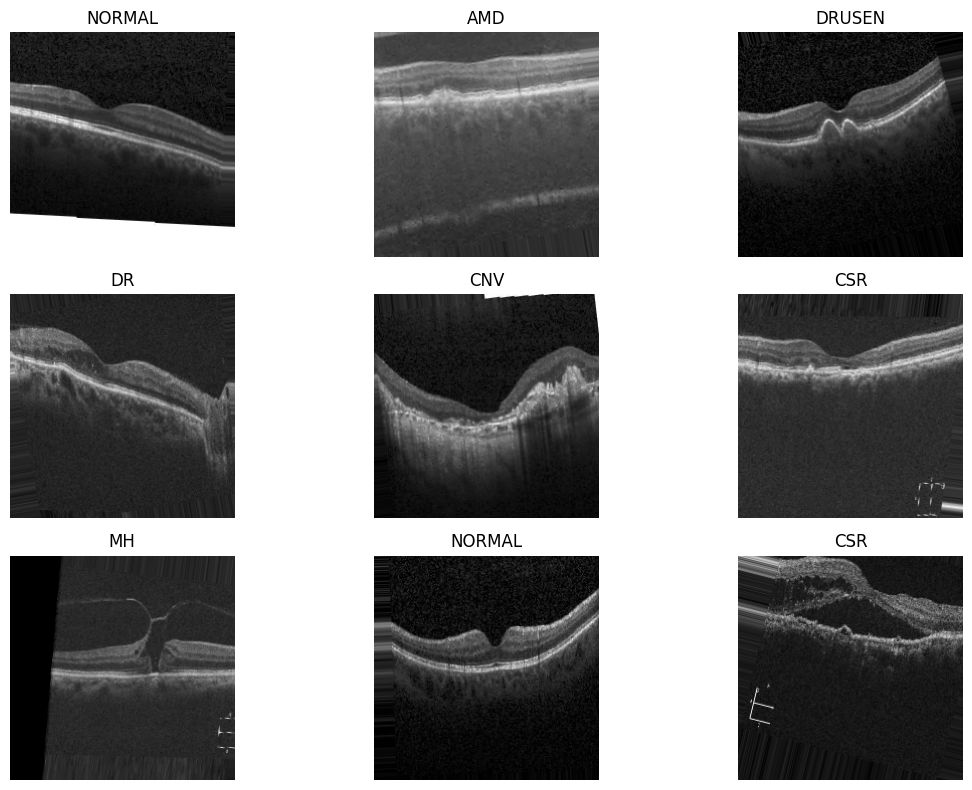

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].astype("uint8"))

    # One-hot encoded label → class index
    label_index = np.argmax(labels[i])

    label = CLASS_NAMES[label_index]

    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Models Define**

1. Xception
2. ResNet50
3. MobileNetV3Large
4. EfficientNetB7
5. DenseNet121
6. InceptionV3

Keras Applications-এ pretrained ImageNet models feature extraction and fine-tuning

In [12]:
from tensorflow.keras.applications import (
    Xception,
    ResNet50,
    MobileNetV3Large,
    EfficientNetB7,
    DenseNet121,
    InceptionV3
)

# **Model Configuration**

In [13]:
MODEL_CONFIGS = {

    "Xception": {
        "model": Xception,
        "input_size": (224, 224)
    },

    "ResNet50": {
        "model": ResNet50,
        "input_size": (224, 224)
    },

    "MobileNetV3Large": {
        "model": MobileNetV3Large,
        "input_size": (224, 224)
    },

    "EfficientNetB7": {
        "model": EfficientNetB7,
        "input_size": (224, 224)
    },

    "DenseNet121": {
        "model": DenseNet121,
        "input_size": (224, 224)
    },

    "InceptionV3": {
        "model": InceptionV3,
        "input_size": (224, 224)
    }
}

# **Transfer Learning Model Function**

In [14]:
def build_transfer_model(base_model_class, input_shape=(224, 224, 3)):

    base_model = base_model_class(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        8,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=keras.optimizers.Adamax(
            learning_rate=1e-4
        ),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

# **Callbacks**

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [16]:
def get_callbacks(model_name):

    os.makedirs("models", exist_ok=True)

    return [

        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=f"models/{model_name}_best.keras",
            monitor="val_accuracy",
            #save_best_only=True,
            verbose=1
        )
        
    ]

# **One Model Train Function**

In [17]:
def train_model(model_name, model_class):

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    model = build_transfer_model(
        model_class,
        input_shape=(*IMG_SIZE, 3)
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_name)
    )

    return model, history

# **Accuracy & Loss Visualization**

In [18]:
def plot_training_history(history, model_name):

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)

    plt.plot(
        history.history["accuracy"],
        label="Train Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(
        history.history["loss"],
        label="Train Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# **Total Model Train**

In [19]:
models = {}
histories = {}

Training: Xception
Epoch 1/5


2026-09-18 05:27:05.420448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:27:05.602785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:27:08.043497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:27:08.182161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:27:09.562782: E external/local_xla/xla/stream_

575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.2911 - loss: 2.0997

2026-09-18 05:33:31.718888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:33:31.874899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:33:33.512143: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:33:33.647221: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 05:33:34.587347: E external/local_xla/xla/stream_


Epoch 1: saving model to models/Xception_best.keras

Epoch 1: finished saving model to models/Xception_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 410s 668ms/step - accuracy: 0.3415 - loss: 1.8665 - val_accuracy: 0.4336 - val_loss: 1.3473 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.4097 - loss: 1.5746
Epoch 2: saving model to models/Xception_best.keras

Epoch 2: finished saving model to models/Xception_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 244s 424ms/step - accuracy: 0.4109 - loss: 1.5542 - val_accuracy: 0.4636 - val_loss: 1.2614 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.4314 - loss: 1.4550
Epoch 3: saving model to models/Xception_best.keras

Epoch 3: finished saving model to models/Xception_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 242s 420ms/step - accuracy: 0.4326 - loss: 1.4432 - val_accuracy: 0.4811 - val_loss: 1.2176 - learning_rate: 1.0000e-04
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━

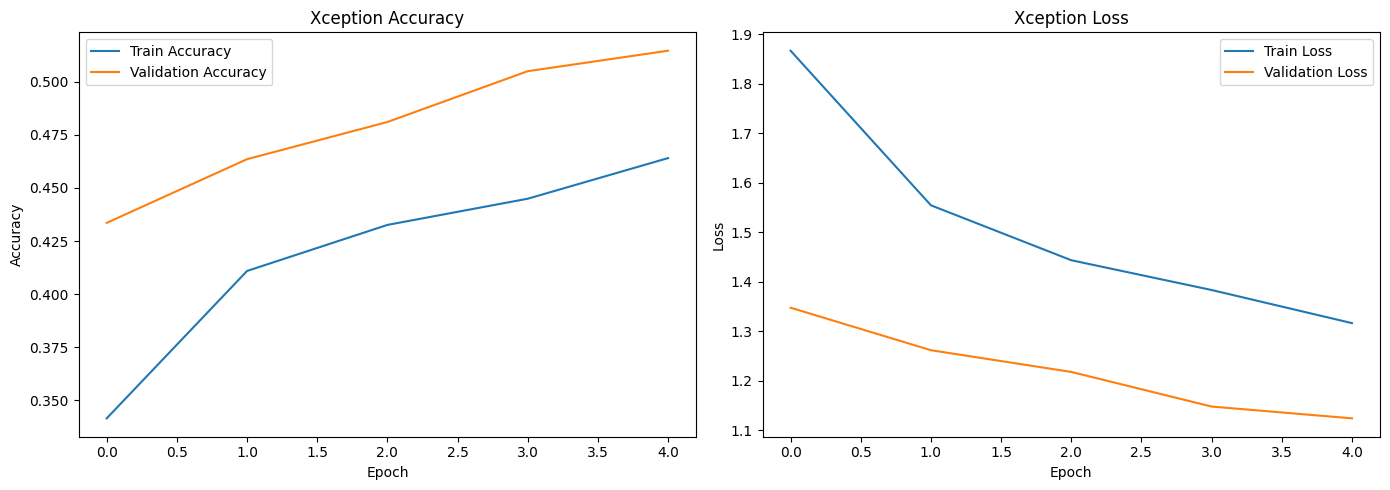

Training: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.3561 - loss: 2.0851
Epoch 1: saving model to models/ResNet50_best.keras

Epoch 1: finished saving model to models/ResNet50_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 257s 423ms/step - accuracy: 0.4802 - loss: 1.5815 - val_accuracy: 0.7579 - val_loss: 0.6603 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6440 - loss: 1.0160
Epoch 2: saving model to models/ResNet50_best.keras

Epoch 2: finished saving model to models/ResNet50_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 235s 409ms/step - accuracy: 0.6555 - loss: 0.9775 - val_accuracy: 0.7907 - val_loss: 0.5746 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6996 - loss: 0.8345
Epoch 3: saving model to models/ResNet50_best.keras

Epoch 3: finished saving model to models/ResNet50_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 

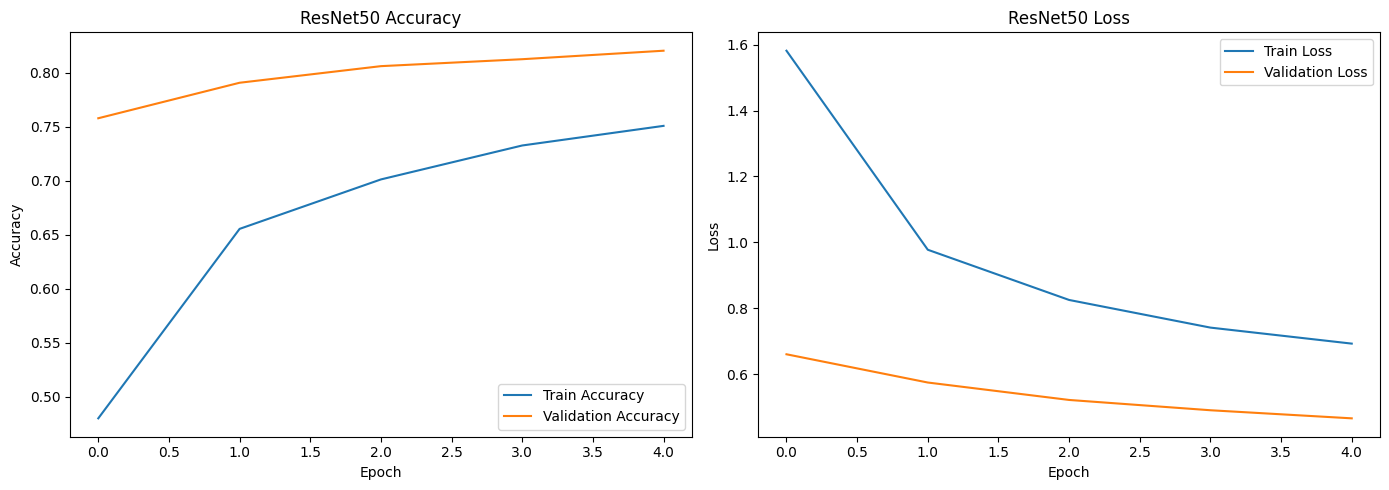

Training: MobileNetV3Large
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


2026-09-18 06:10:07.465654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:10:07.604599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:10:07.947200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:10:08.084575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.2657 - loss: 2.2896

2026-09-18 06:14:10.119955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:14:10.254509: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:14:10.576122: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:14:10.713531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: saving model to models/MobileNetV3Large_best.keras

Epoch 1: finished saving model to models/MobileNetV3Large_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 261s 422ms/step - accuracy: 0.3735 - loss: 1.8541 - val_accuracy: 0.6739 - val_loss: 0.8819 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5499 - loss: 1.2491
Epoch 2: saving model to models/MobileNetV3Large_best.keras

Epoch 2: finished saving model to models/MobileNetV3Large_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 226s 392ms/step - accuracy: 0.5793 - loss: 1.1581 - val_accuracy: 0.7404 - val_loss: 0.6820 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.6318 - loss: 0.9881
Epoch 3: saving model to models/MobileNetV3Large_best.keras

Epoch 3: finished saving model to models/MobileNetV3Large_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 226s 393ms/step - accuracy: 0.6421 - loss: 0.9596 - val_accuracy: 0.7746 - val_loss: 0.5951 - learning_rate:

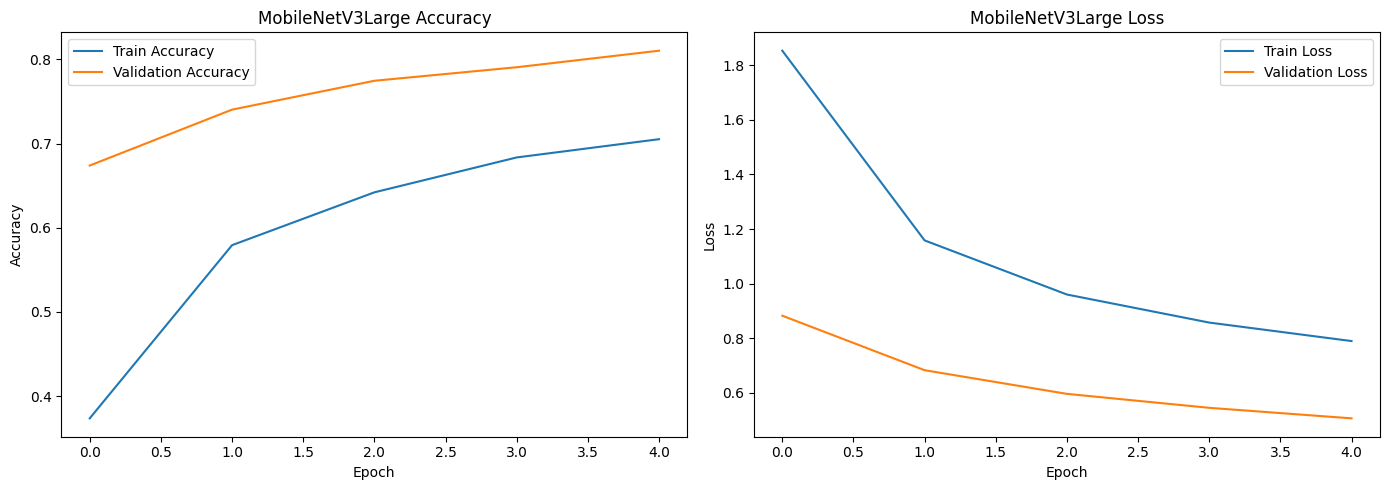

Training: EfficientNetB7
258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5


2026-09-18 06:30:40.291529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:30:40.437405: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:30:40.740273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:30:40.891772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:30:41.416055: E external/local_xla/xla/stream_

575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.3465 - loss: 2.1398

2026-09-18 06:36:13.397866: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:36:13.536508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:36:13.795098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:36:13.941498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 06:36:14.249415: E external/local_xla/xla/stream_


Epoch 1: saving model to models/EfficientNetB7_best.keras

Epoch 1: finished saving model to models/EfficientNetB7_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 402s 549ms/step - accuracy: 0.4547 - loss: 1.6960 - val_accuracy: 0.7571 - val_loss: 0.7167 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.6077 - loss: 1.1572
Epoch 2: saving model to models/EfficientNetB7_best.keras

Epoch 2: finished saving model to models/EfficientNetB7_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 276s 480ms/step - accuracy: 0.6236 - loss: 1.0975 - val_accuracy: 0.8071 - val_loss: 0.5568 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.6574 - loss: 0.9751
Epoch 3: saving model to models/EfficientNetB7_best.keras

Epoch 3: finished saving model to models/EfficientNetB7_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 273s 475ms/step - accuracy: 0.6699 - loss: 0.9498 - val_accuracy: 0.8268 - val_loss: 0.5003 - learning_rate: 1.0000e-04


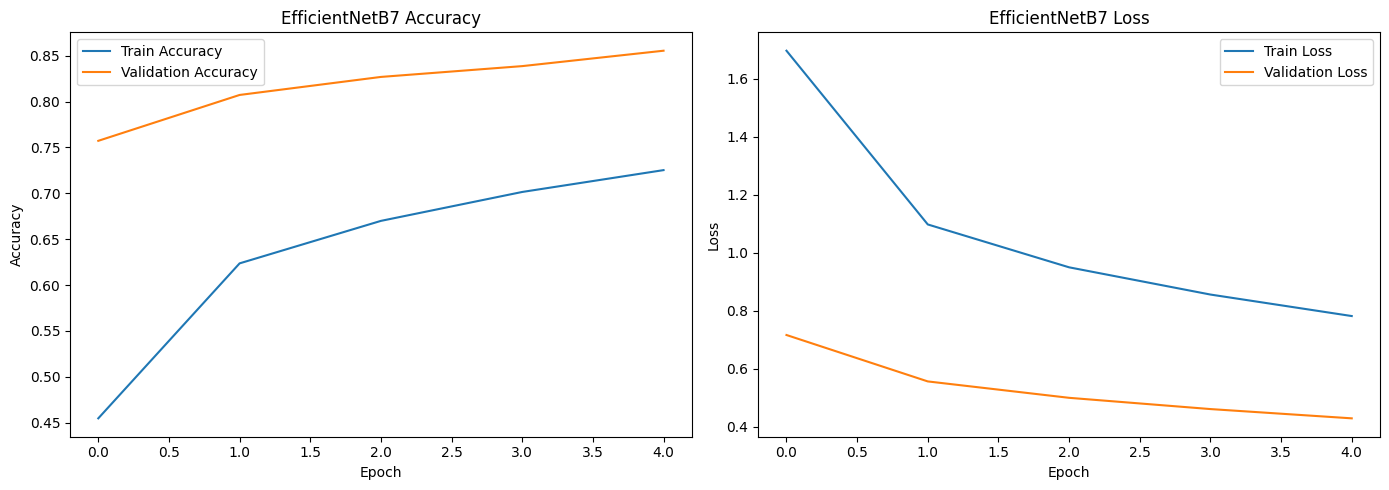

Training: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3181 - loss: 1.9041
Epoch 1: saving model to models/DenseNet121_best.keras

Epoch 1: finished saving model to models/DenseNet121_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 286s 448ms/step - accuracy: 0.3877 - loss: 1.6504 - val_accuracy: 0.5000 - val_loss: 1.3448 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.4847 - loss: 1.3080
Epoch 2: saving model to models/DenseNet121_best.keras

Epoch 2: finished saving model to models/DenseNet121_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 237s 412ms/step - accuracy: 0.5036 - loss: 1.2636 - val_accuracy: 0.5457 - val_loss: 1.1703 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5477 - loss: 1.1342
Epoch 3: saving model to models/DenseNet121_best.keras

Epoch 3: finished saving model to models/DenseNet121_best.keras
575/575 

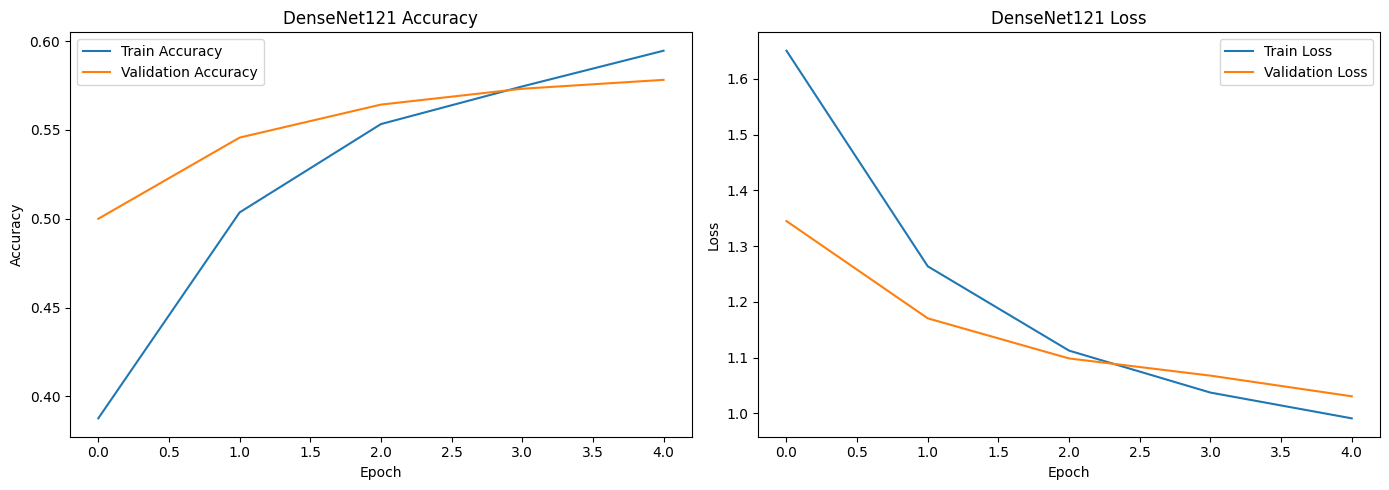

Training: InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.2707 - loss: 2.4388
Epoch 1: saving model to models/InceptionV3_best.keras

Epoch 1: finished saving model to models/InceptionV3_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 268s 435ms/step - accuracy: 0.3283 - loss: 2.0997 - val_accuracy: 0.4636 - val_loss: 1.3292 - learning_rate: 1.0000e-04
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.3920 - loss: 1.7548
Epoch 2: saving model to models/InceptionV3_best.keras

Epoch 2: finished saving model to models/InceptionV3_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 249s 433ms/step - accuracy: 0.4084 - loss: 1.6858 - val_accuracy: 0.5057 - val_loss: 1.2048 - learning_rate: 1.0000e-04
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4408 - loss: 1.5686
Epoch 3: saving model to models/InceptionV3_best.keras

Epoch 3: finished saving model to models/InceptionV3_best.keras
575/575 

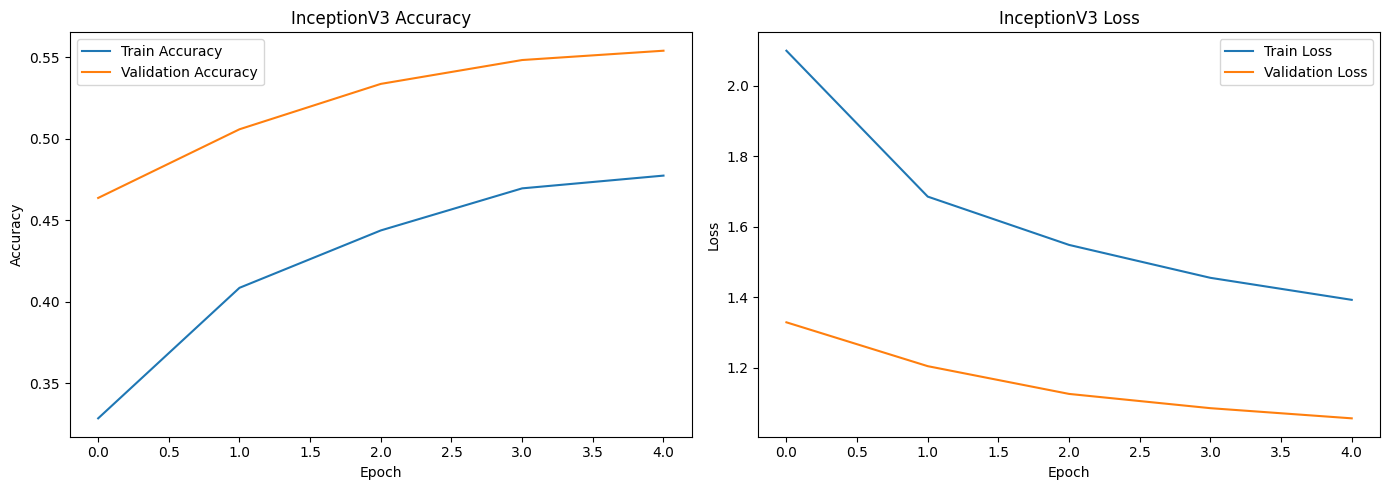

In [20]:
for model_name, config in MODEL_CONFIGS.items():

    model, history = train_model(
        model_name,
        config["model"]
    )

    models[model_name] = model
    histories[model_name] = history

    plot_training_history(
        history,
        model_name
    )

    # Memory clean
    gc.collect()

# **Test Prediction Function**

In [21]:
def get_predictions(model):

    test_generator.reset()

    probabilities = model.predict(
        test_generator,
        verbose=1
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    true_labels = test_generator.classes

    return true_labels, predictions, probabilities

# **Accuracy, Precision, Recall, F1**

In [24]:
def evaluate_model(model, model_name):

    # Get predictions
    y_true, y_pred, probabilities = get_predictions(model)

    # Metrics
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Classification Report
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=list(test_generator.class_indices.keys()),
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=test_generator.class_indices.keys(),
        yticklabels=test_generator.class_indices.keys()
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

# **Total Model Evaluate**

88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step

Xception
Accuracy  : 0.5036
Precision : 0.5029
Recall    : 0.5036
F1 Score  : 0.4996

Classification Report:

              precision    recall  f1-score   support

          DR       0.47      0.57      0.52       350
         AMD       0.99      0.97      0.98       350
         CSR       0.53      0.54      0.53       350
      DRUSEN       0.36      0.32      0.34       350
         CNV       0.41      0.46      0.43       350
      NORMAL       0.41      0.50      0.45       350
          MH       0.47      0.41      0.44       350
         DME       0.39      0.26      0.31       350

    accuracy                           0.50      2800
   macro avg       0.50      0.50      0.50      2800
weighted avg       0.50      0.50      0.50      2800



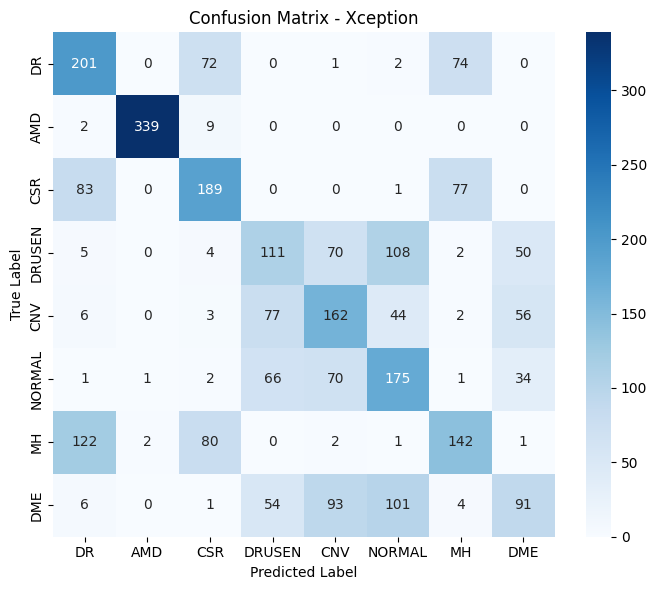

88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step

ResNet50
Accuracy  : 0.8179
Precision : 0.8255
Recall    : 0.8179
F1 Score  : 0.8150

Classification Report:

              precision    recall  f1-score   support

          DR       0.91      0.80      0.85       350
         AMD       1.00      0.97      0.98       350
         CSR       0.86      1.00      0.92       350
      DRUSEN       0.71      0.53      0.61       350
         CNV       0.70      0.82      0.75       350
      NORMAL       0.67      0.88      0.76       350
          MH       0.95      0.90      0.92       350
         DME       0.82      0.64      0.72       350

    accuracy                           0.82      2800
   macro avg       0.83      0.82      0.81      2800
weighted avg       0.83      0.82      0.81      2800



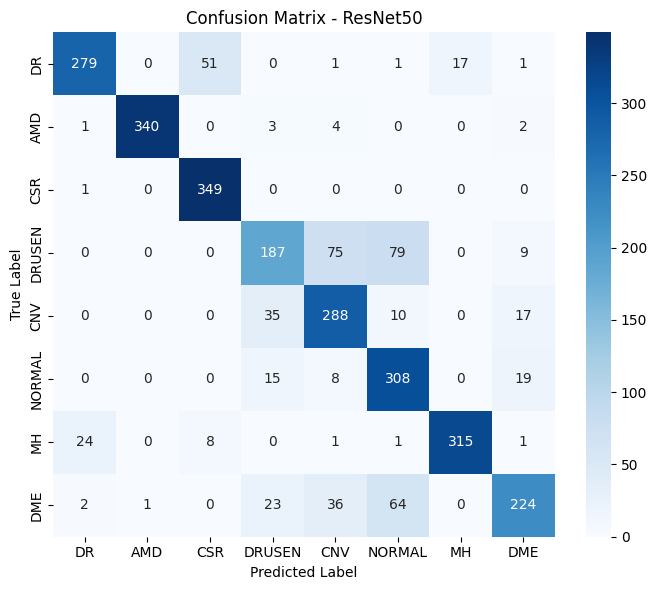

88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step

MobileNetV3Large
Accuracy  : 0.8186
Precision : 0.8266
Recall    : 0.8186
F1 Score  : 0.8199

Classification Report:

              precision    recall  f1-score   support

          DR       0.86      0.87      0.86       350
         AMD       0.99      0.97      0.98       350
         CSR       0.89      0.94      0.91       350
      DRUSEN       0.60      0.77      0.67       350
         CNV       0.78      0.73      0.75       350
      NORMAL       0.75      0.76      0.75       350
          MH       0.93      0.86      0.89       350
         DME       0.81      0.65      0.72       350

    accuracy                           0.82      2800
   macro avg       0.83      0.82      0.82      2800
weighted avg       0.83      0.82      0.82      2800



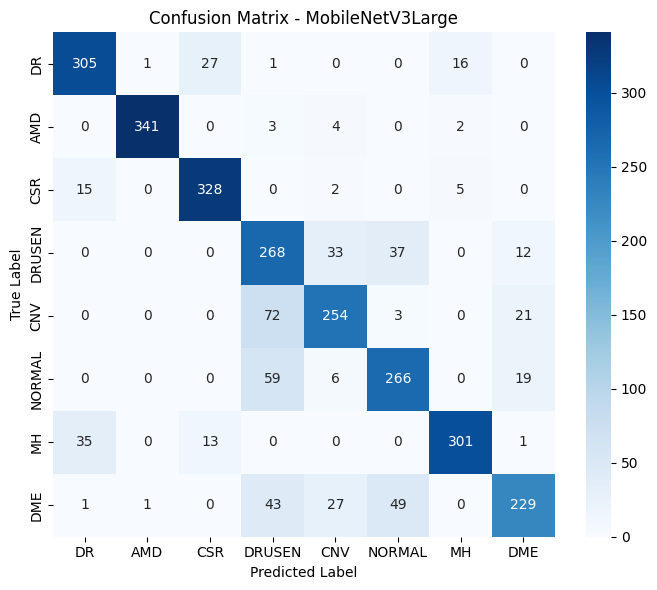

88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 498ms/step

EfficientNetB7
Accuracy  : 0.8439
Precision : 0.8466
Recall    : 0.8439
F1 Score  : 0.8425

Classification Report:

              precision    recall  f1-score   support

          DR       0.93      0.87      0.90       350
         AMD       0.94      0.95      0.94       350
         CSR       0.89      0.97      0.93       350
      DRUSEN       0.70      0.76      0.73       350
         CNV       0.80      0.69      0.74       350
      NORMAL       0.74      0.89      0.81       350
          MH       0.95      0.96      0.95       350
         DME       0.82      0.67      0.74       350

    accuracy                           0.84      2800
   macro avg       0.85      0.84      0.84      2800
weighted avg       0.85      0.84      0.84      2800



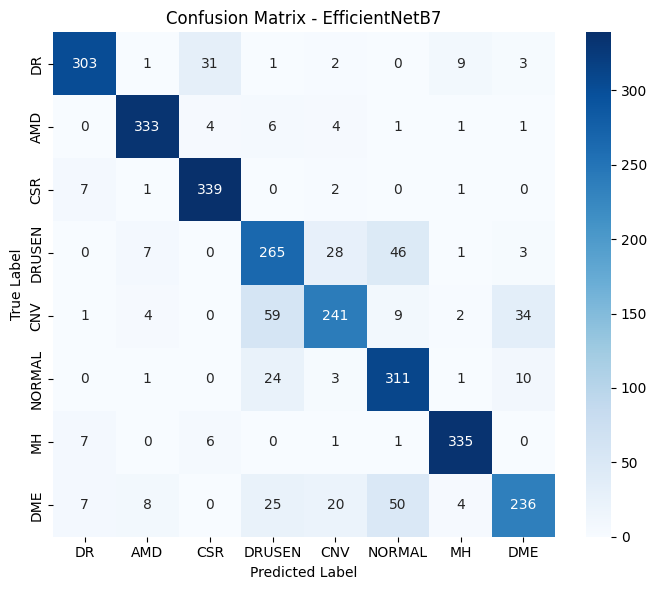

88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 262ms/step

DenseNet121
Accuracy  : 0.5618
Precision : 0.6045
Recall    : 0.5618
F1 Score  : 0.5325

Classification Report:

              precision    recall  f1-score   support

          DR       0.79      0.38      0.51       350
         AMD       0.99      0.99      0.99       350
         CSR       0.47      0.94      0.62       350
      DRUSEN       0.40      0.39      0.39       350
         CNV       0.51      0.66      0.58       350
      NORMAL       0.49      0.75      0.59       350
          MH       0.87      0.25      0.39       350
         DME       0.33      0.13      0.18       350

    accuracy                           0.56      2800
   macro avg       0.60      0.56      0.53      2800
weighted avg       0.60      0.56      0.53      2800



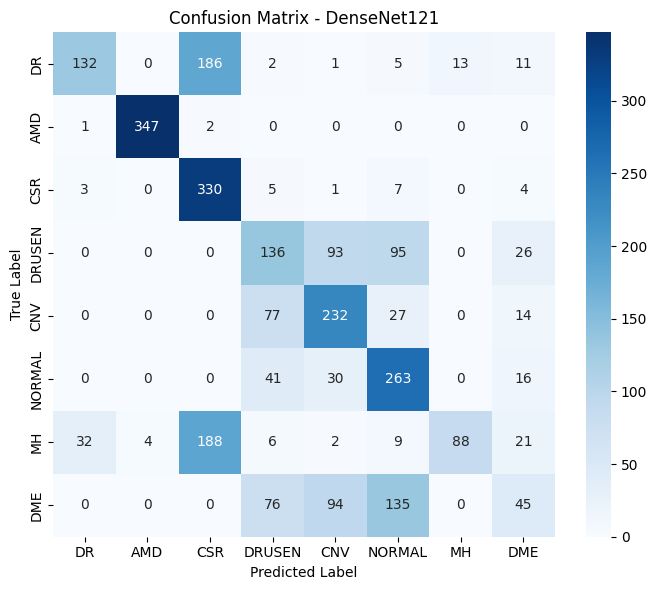

88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 185ms/step

InceptionV3
Accuracy  : 0.5621
Precision : 0.5745
Recall    : 0.5621
F1 Score  : 0.5560

Classification Report:

              precision    recall  f1-score   support

          DR       0.62      0.49      0.54       350
         AMD       0.99      0.96      0.98       350
         CSR       0.60      0.78      0.68       350
      DRUSEN       0.40      0.30      0.34       350
         CNV       0.56      0.45      0.50       350
      NORMAL       0.41      0.73      0.52       350
          MH       0.62      0.42      0.50       350
         DME       0.40      0.38      0.39       350

    accuracy                           0.56      2800
   macro avg       0.57      0.56      0.56      2800
weighted avg       0.57      0.56      0.56      2800



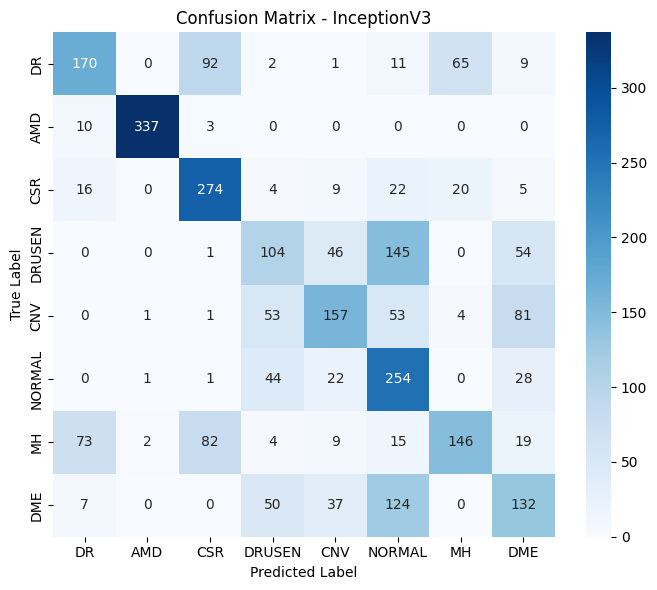

,Model,Accuracy,Precision,Recall,F1 Score
0,Xception,0.503571,0.502877,0.503571,0.499577
1,ResNet50,0.817857,0.825519,0.817857,0.814976
2,MobileNetV3Large,0.818571,0.826577,0.818571,0.819889
3,EfficientNetB7,0.843929,0.846640,0.843929,0.842528
4,DenseNet121,0.561786,0.604534,0.561786,0.532549
5,InceptionV3,0.562143,0.574461,0.562143,0.556032


In [25]:
results = []

for model_name, model in models.items():

    result = evaluate_model(
        model,
        model_name
    )

    results.append(result)

results_df = pd.DataFrame(results)

results_df

# **Accuracy Comparison**

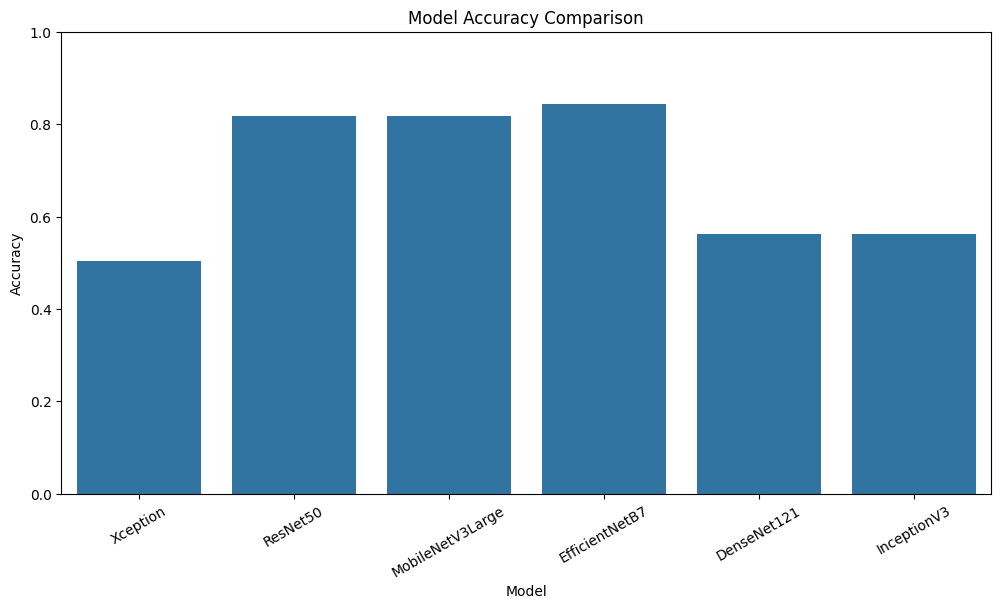

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

# **Precision Comparison**

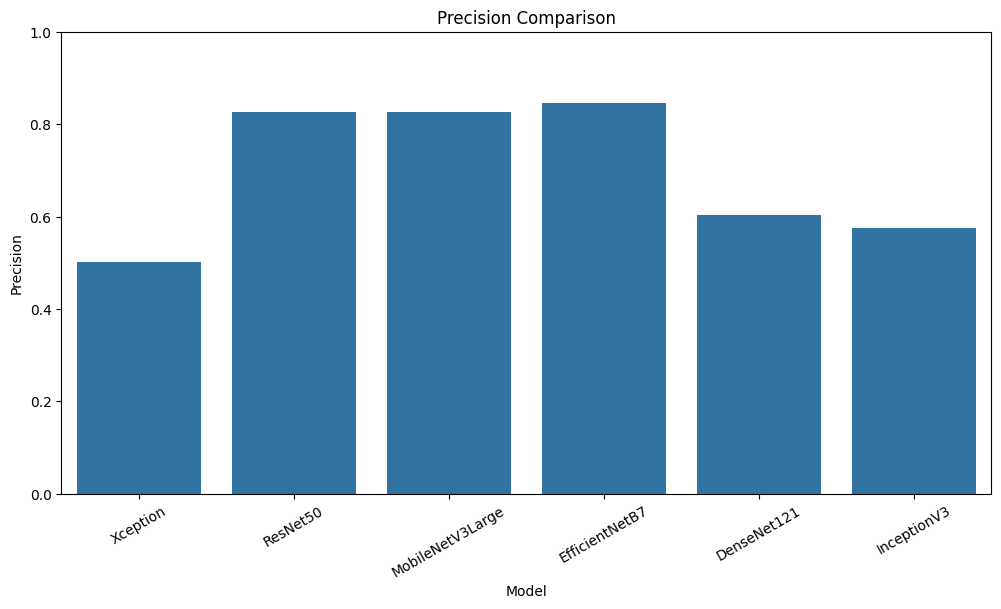

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.ylim(0, 1)

plt.title("Precision Comparison")

plt.xticks(rotation=30)

plt.show()

# **Recall Comparison**

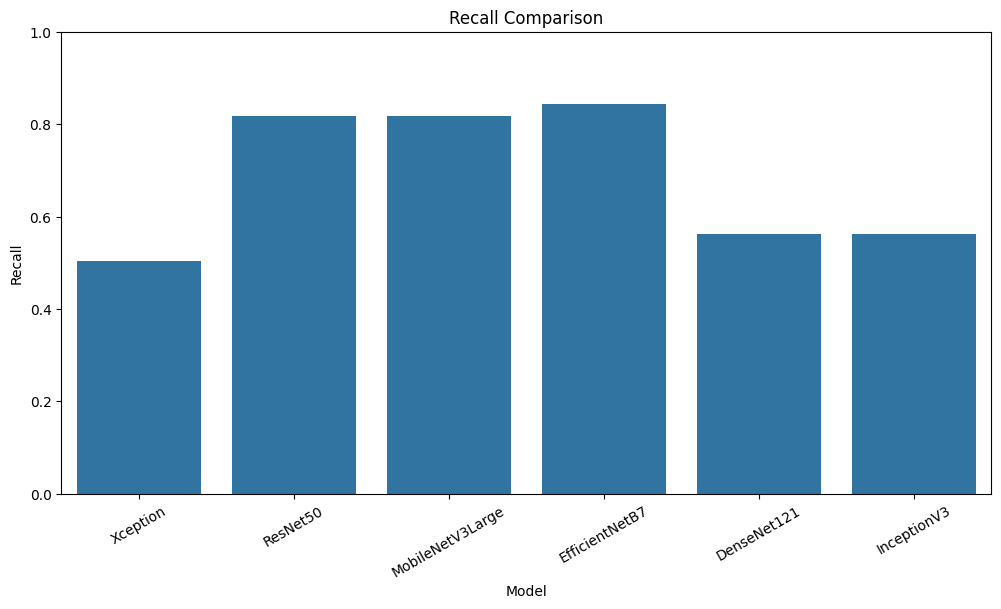

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.ylim(0, 1)

plt.title("Recall Comparison")

plt.xticks(rotation=30)

plt.show()

# **F1-Score Comparison**

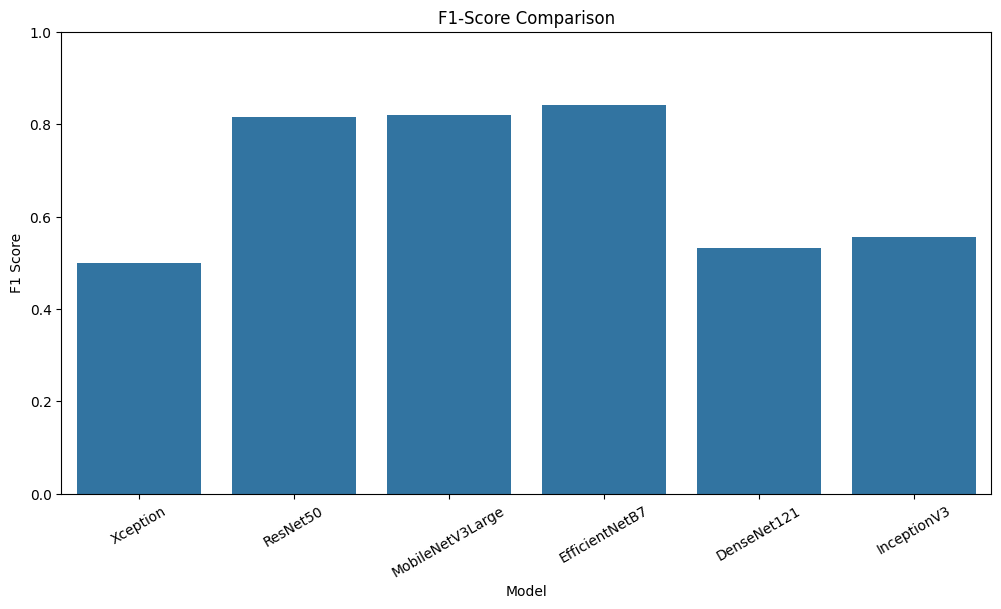

In [32]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.ylim(0, 1)

plt.title("F1-Score Comparison")

plt.xticks(rotation=30)

plt.show()

# **Total Metrics**

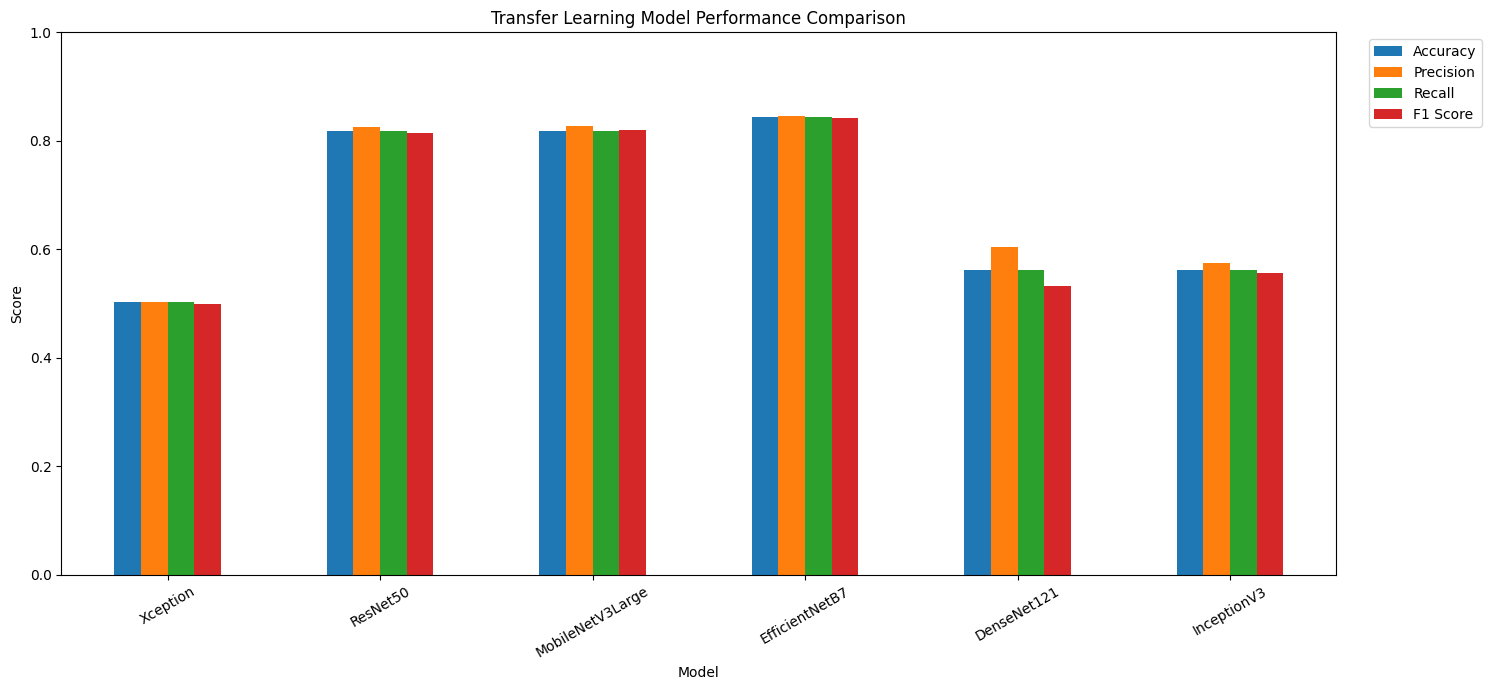

In [35]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.ylim(0, 1)

plt.title(
    "Transfer Learning Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# **Confusion Matrix**

In [36]:
def plot_confusion_matrix(model, model_name):

    y_true, y_pred, _ = get_predictions(model)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step


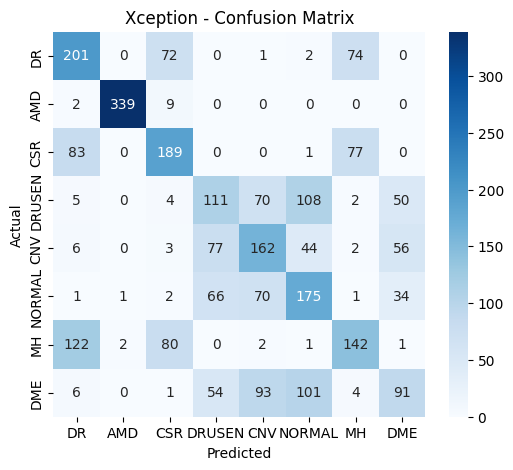

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step


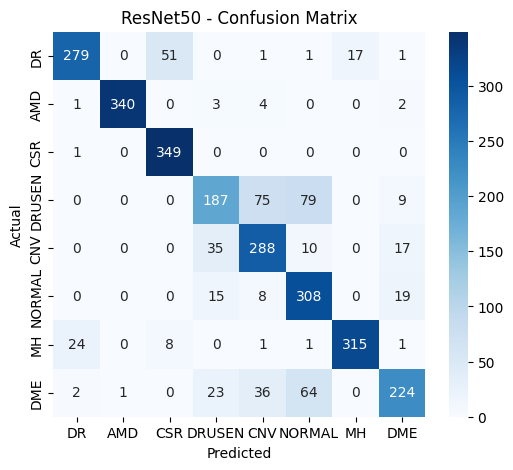

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step


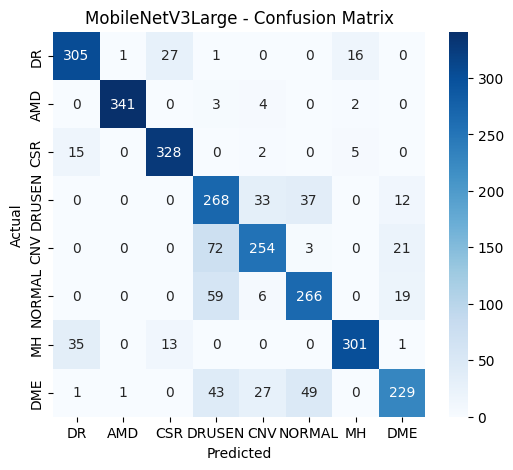

88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 266ms/step


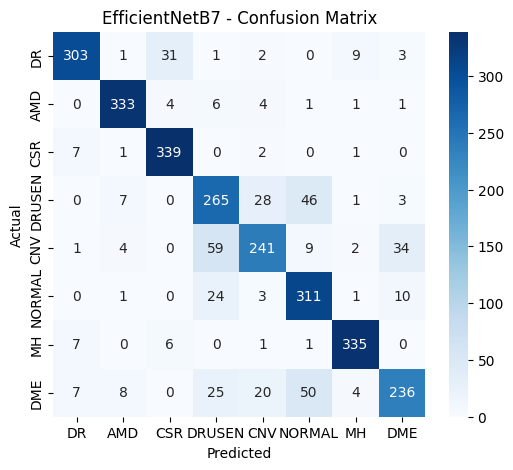

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step


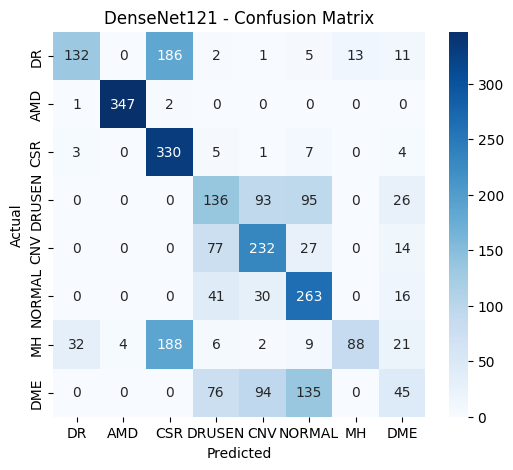

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step


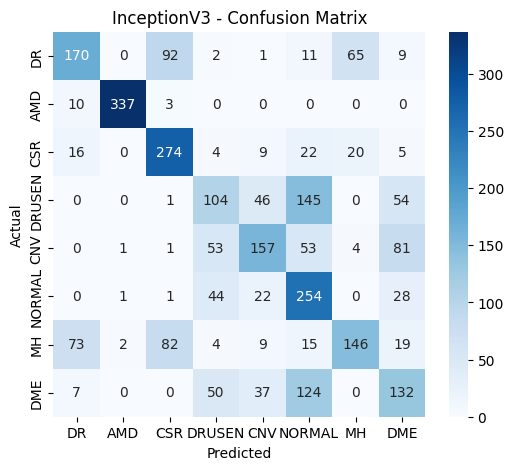

In [37]:
for model_name, model in models.items():

    plot_confusion_matrix(
        model,
        model_name
    )

# **Classification Report**

In [38]:
for model_name, model in models.items():

    y_true, y_pred, _ = get_predictions(model)

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4
        )
    )

88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step


Xception
              precision    recall  f1-score   support

          DR     0.4718    0.5743    0.5180       350
         AMD     0.9912    0.9686    0.9798       350
         CSR     0.5250    0.5400    0.5324       350
      DRUSEN     0.3604    0.3171    0.3374       350
         CNV     0.4070    0.4629    0.4332       350
      NORMAL     0.4051    0.5000    0.4476       350
          MH     0.4702    0.4057    0.4356       350
         DME     0.3922    0.2600    0.3127       350

    accuracy                         0.5036      2800
   macro avg     0.5029    0.5036    0.4996      2800
weighted avg     0.5029    0.5036    0.4996      2800

88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step


ResNet50
              precision    recall  f1-score   support

          DR     0.9088    0.7971    0.8493       350
         AMD     0.9971    0.9714    0.9841       350
         CSR     0.8554    0.9971    0.9208       350
      DRUSEN     0.7110   

# **ROC Curve**

88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step


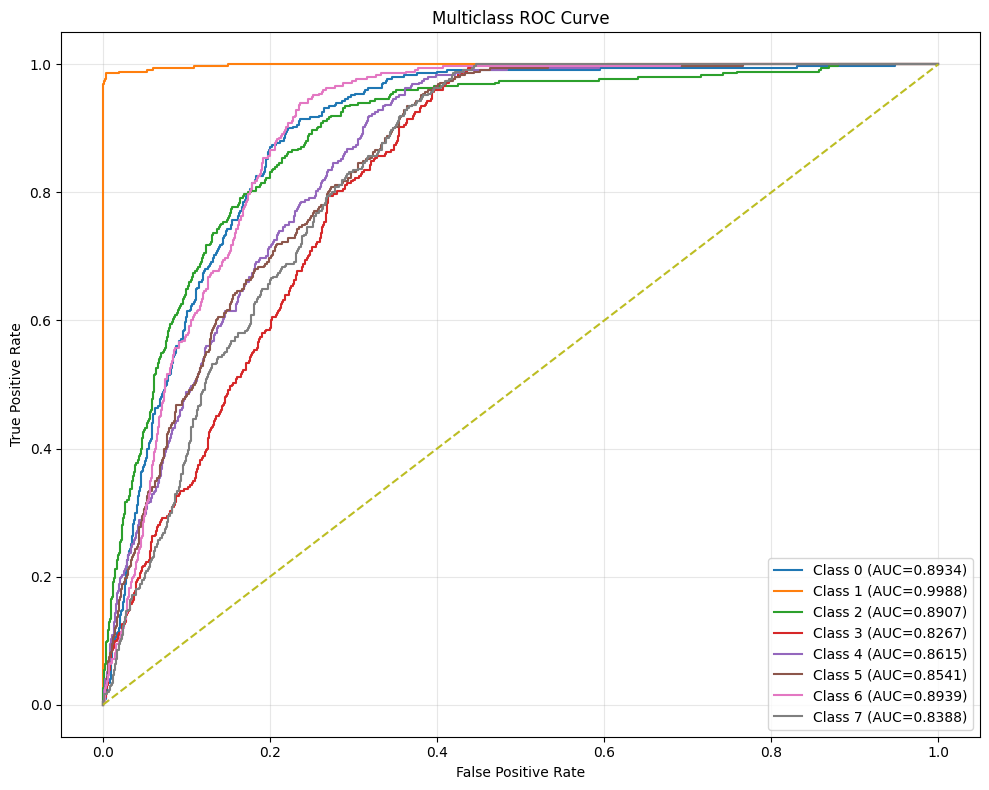

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

n_classes = len(test_generator.class_indices)

y_true, y_pred, y_prob = get_predictions(
    list(models.values())[0]
)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

plt.figure(figsize=(10, 8))

for class_id in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, class_id],
        y_prob[:, class_id]
    )

    auc_score = roc_auc_score(
        y_true_bin[:, class_id],
        y_prob[:, class_id]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_id} (AUC={auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Heatmap — Model vs Metrics**

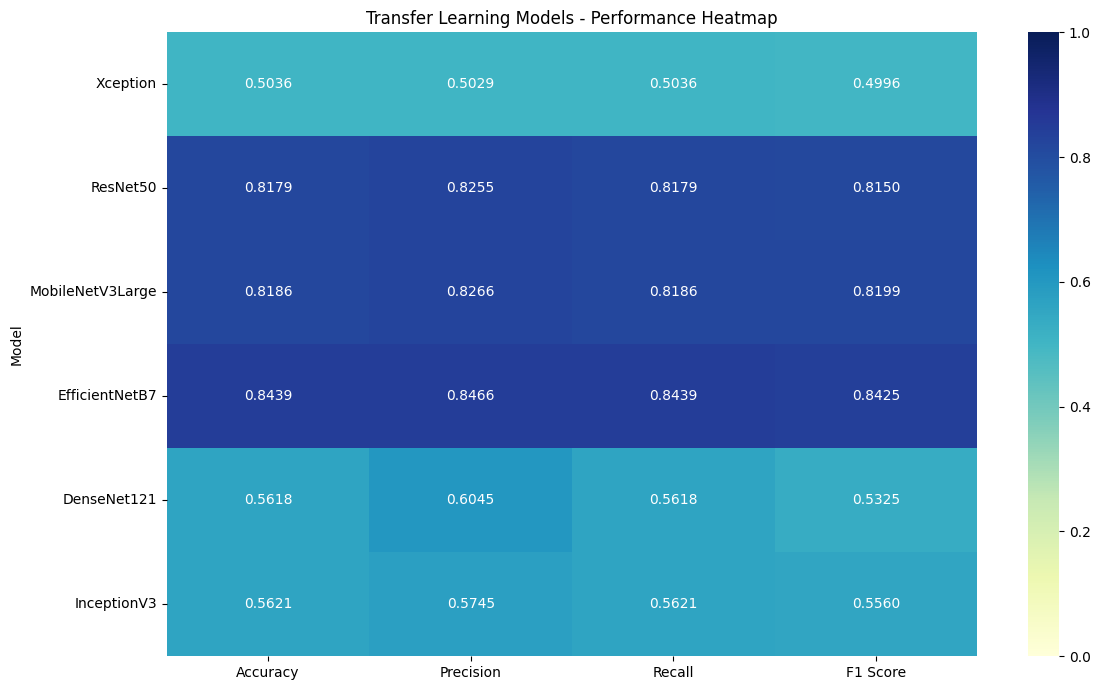

In [42]:
heatmap_data = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
    ]
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title(
    "Transfer Learning Models - Performance Heatmap"
)

plt.tight_layout()

plt.show()

# **Find Best Model**

In [43]:
print("Highest Accuracy:")
print(
    results_df.loc[
        results_df["Accuracy"].idxmax()
    ]
)

print("\nHighest Precision:")
print(
    results_df.loc[
        results_df["Precision"].idxmax()
    ]
)

print("\nHighest Recall:")
print(
    results_df.loc[
        results_df["Recall"].idxmax()
    ]
)

print("\nHighest F1:")
print(
    results_df.loc[
        results_df["F1 Score"].idxmax()
    ]
)


Highest Accuracy:
Model        EfficientNetB7
Accuracy           0.843929
Precision           0.84664
Recall             0.843929
F1 Score           0.842528
Name: 3, dtype: object

Highest Precision:
Model        EfficientNetB7
Accuracy           0.843929
Precision           0.84664
Recall             0.843929
F1 Score           0.842528
Name: 3, dtype: object

Highest Recall:
Model        EfficientNetB7
Accuracy           0.843929
Precision           0.84664
Recall             0.843929
F1 Score           0.842528
Name: 3, dtype: object

Highest F1:
Model        EfficientNetB7
Accuracy           0.843929
Precision           0.84664
Recall             0.843929
F1 Score           0.842528
Name: 3, dtype: object


# **Overall Comparison**

In [45]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,EfficientNetB7,0.843929,0.846640,0.843929,0.842528
2,MobileNetV3Large,0.818571,0.826577,0.818571,0.819889
1,ResNet50,0.817857,0.825519,0.817857,0.814976
5,InceptionV3,0.562143,0.574461,0.562143,0.556032
4,DenseNet121,0.561786,0.604534,0.561786,0.532549
0,Xception,0.503571,0.502877,0.503571,0.499577


# **Fine-Tuning — 2nd Stage**

Stage-1 Transfer Learning।

In [46]:
def prepare_fine_tuning(model, unfreeze_from=-30):

    base_model = None

    for layer in model.layers:

        if hasattr(layer, "layers"):

            if "conv" in layer.name.lower() or \
               "efficient" in layer.name.lower() or \
               "resnet" in layer.name.lower() or \
               "xception" in layer.name.lower() or \
               "densenet" in layer.name.lower():

                base_model = layer

    if base_model is None:
        print("Base model not found.")
        return model

    base_model.trainable = True

    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    for layer in base_model.layers[unfreeze_from:]:
        layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adamax(
            learning_rate=1e-5
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [47]:
fine_tuned_model = prepare_fine_tuning(
    models["Xception"],
    unfreeze_from=-30
)

In [48]:
history_ft = fine_tuned_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=get_callbacks("Xception_FineTuned")
)

Epoch 1/10


2026-09-18 08:21:36.654596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 08:21:36.795131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.2956 - loss: 1.9064
Epoch 1: saving model to models/Xception_FineTuned_best.keras

Epoch 1: finished saving model to models/Xception_FineTuned_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 306s 497ms/step - accuracy: 0.3369 - loss: 1.7305 - val_accuracy: 0.4161 - val_loss: 1.3205 - learning_rate: 1.0000e-05
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.3841 - loss: 1.5503
Epoch 2: saving model to models/Xception_FineTuned_best.keras

Epoch 2: finished saving model to models/Xception_FineTuned_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 270s 468ms/step - accuracy: 0.3926 - loss: 1.5104 - val_accuracy: 0.4564 - val_loss: 1.2180 - learning_rate: 1.0000e-05
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.4118 - loss: 1.4200
Epoch 3: saving model to models/Xception_FineTuned_best.keras

Epoch 3: finished saving model to models/Xception_FineTuned_best.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 261s 454ms/step - 